# 01 · Data and stylized facts

**What this notebook shows:** the raw story before any regression.
1. India's terms of trade (ToT) against the real oil price since 1970, with the oil-shock episodes marked.
2. The monthly picture for 2019–2026, which covers the COVID crash, the 2022 Russia–Ukraine spike and the 2026 Hormuz crisis.
3. How exposed India is: oil's share in exports and imports, and the **theory benchmark** s_x − s_m.
4. Descriptive statistics and an episode table.

The data are built by `src/build_dataset.py` from official sources (listed in `data/SOURCES.md`) and checked by `src/validate_dataset.py`.

In [1]:
# Shared setup: the helper modules live in ../src (chart style, econometrics helpers, data loader)
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from style import *
import econ
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
m, a, c = econ.load()

## 1. Terms of trade vs the real oil price, FY1970-71 to FY2025-26

- **ToT (goods & services)** = export deflator / import deflator (World Bank WDI national accounts).
- **ToT (merchandise)** = DGCI&S export unit value index / import unit value index (chain-linked RBI series).
- Both are rebased to FY2015-16 = 100.
- **Real oil price** = average crude price (Brent, Dubai, WTI) / MUV index, i.e. oil priced in terms of manufactures.

Two panels share the time axis rather than using two y-axes.

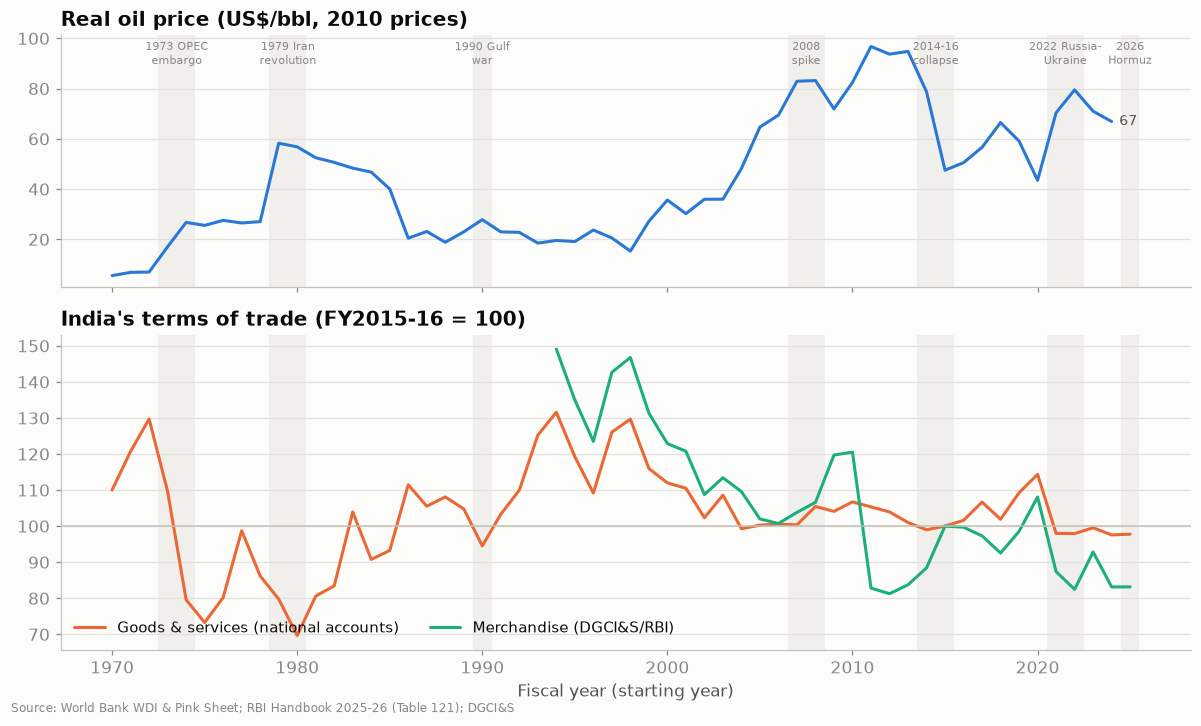

In [2]:
d = a.loc[1970:2025].copy()
d["ntt_merch_2015"] = 100 * d.ntt_rbi_chained / d.loc[2015, "ntt_rbi_chained"]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.6), sharex=True, gridspec_kw={"height_ratios": [1, 1.25]})
shade_episodes(ax1); shade_episodes(ax2, label=False)
ax1.plot(d.index, d.real_oil_avg, color=BLUE)
ax1.set_title("Real oil price (US$/bbl, 2010 prices)")
ax1.annotate(f"{d.real_oil_avg.dropna().iloc[-1]:.0f}", (d.real_oil_avg.dropna().index[-1], d.real_oil_avg.dropna().iloc[-1]),
             xytext=(5, 0), textcoords="offset points", va="center", fontsize=9, color=INK2)
ax2.plot(d.index, d.tot_gs_na, color=ORANGE, label="Goods & services (national accounts)")
ax2.plot(d.index, d.ntt_merch_2015, color=AQUA, label="Merchandise (DGCI&S/RBI)")
ax2.axhline(100, color=AXIS, lw=1)
ax2.set_title("India's terms of trade (FY2015-16 = 100)")
ax2.legend(loc="lower left", ncol=2)
ax2.set_xlabel("Fiscal year (starting year)")
fig.tight_layout()
save(fig, "fig01_tot_vs_real_oil_annual", "World Bank WDI & Pink Sheet; RBI Handbook 2025-26 (Table 121); DGCI&S")
plt.show()

**Reading the chart.** Every big oil-price jump coincides with a fall in India's ToT:
- 1973-74
- 1979-80
- 1990 (which preceded India's 1991 BoP crisis)
- 2008
- 2022

Collapses (1986, 2014-16, 2020) coincide with ToT gains. This is offer-curve **case A/D** in `docs/01_theory_framework.md`.

In [3]:
episodes = [("1973 OPEC embargo", 1972, 1974), ("1979 Iranian revolution", 1978, 1980), ("1990 Gulf war", 1989, 1990),
            ("2008 price spike", 2006, 2008), ("2014-16 price collapse", 2013, 2015), ("2020 COVID crash", 2019, 2020),
            ("2022 Russia-Ukraine", 2020, 2022)]
rows = []
for name, s, e in episodes:
    pct = lambda col: 100 * (a.loc[e, col] / a.loc[s, col] - 1) if pd.notna(a.loc[s, col]) and pd.notna(a.loc[e, col]) else np.nan
    rows.append({"Episode": name, "From FY": f"{s}-{str(s+1)[-2:]}", "To FY": f"{e}-{str(e+1)[-2:]}",
                 "Real oil price, % change": pct("real_oil_avg"), "ToT goods & services, % change": pct("tot_gs_na"),
                 "ToT merchandise, % change": pct("ntt_rbi_chained")})
ep = pd.DataFrame(rows).set_index("Episode")
save_table(ep, "t10_episodes", floatfmt=".1f")
ep

,From FY,To FY,"Real oil price, % change","ToT goods & services, % change","ToT merchandise, % change"
Episode,,,,,
1973 OPEC embargo,1972-73,1974-75,284.058,-38.648,NaN
1979 Iranian revolution,1978-79,1980-81,110.227,-19.182,NaN
1990 Gulf war,1989-90,1990-91,21.087,-9.801,NaN
2008 price spike,2006-07,2008-09,19.852,4.891,5.831
2014-16 price collapse,2013-14,2015-16,-49.896,-0.982,19.438
2020 COVID crash,2019-20,2020-21,-26.408,4.673,9.649
2022 Russia-Ukraine,2020-21,2022-23,82.804,-14.355,-23.705


## 2. The monthly picture, April 2019 – June 2026 (DGCI&S, base 2012-13)

The monthly merchandise ToT is noisy, so a 3-month moving average is shown as well. Brent is from the World Bank Pink Sheet; the Indian basket is from PPAC.

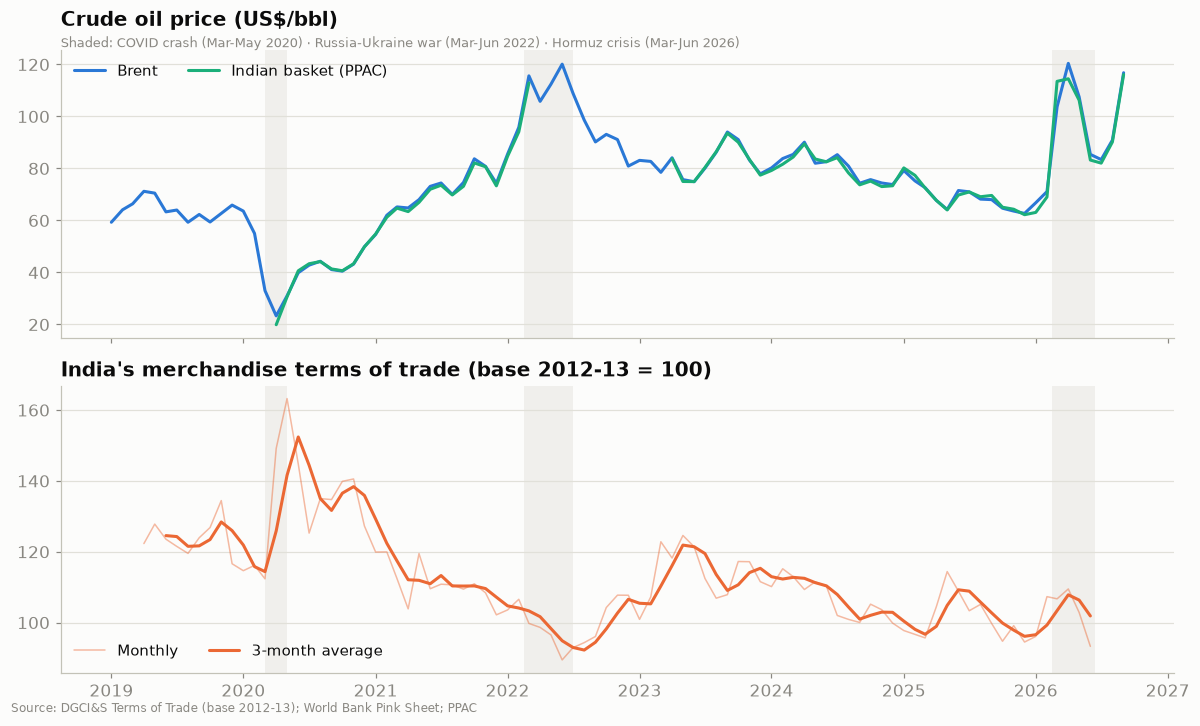

2022 shock  Feb->Jun 2022: Brent +25.4%, merchandise ToT -16.1%
2026 Hormuz Feb->Jun 2026: Brent +20.1% (peak Apr +69.3%), merchandise ToT -13.1%
2026 Hormuz Feb->Apr 2026: export UVI +18.1%, import UVI +15.7%


In [4]:
mm = m.loc["2019-01":"2026-09"].copy()
mm["ntt_ma3"] = mm.ntt_b12.rolling(3).mean()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.6), sharex=True)
for ax in (ax1, ax2):
    for s, e in [("2020-03-01", "2020-05-01"), ("2022-02-15", "2022-07-01"), ("2026-02-15", "2026-06-15")]:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color=SHADE, lw=0, zorder=0)
ax1.plot(mm.index, mm.brent, color=BLUE, label="Brent")
ax1.plot(mm.index, mm.icb_ppac, color=AQUA, label="Indian basket (PPAC)")
ax1.legend(loc="upper left", ncol=2)
ax1.text(0, 1.0, "Shaded: COVID crash (Mar-May 2020) · Russia-Ukraine war (Mar-Jun 2022) · Hormuz crisis (Mar-Jun 2026)",
         transform=ax1.transAxes, ha="left", va="bottom", fontsize=8.5, color=MUTED)
ax1.set_title("Crude oil price (US$/bbl)", pad=16)
ax2.plot(mm.index, mm.ntt_b12, color=ORANGE, lw=1, alpha=0.45, label="Monthly")
ax2.plot(mm.index, mm.ntt_ma3, color=ORANGE, label="3-month average")
ax2.set_title("India's merchandise terms of trade (base 2012-13 = 100)"); ax2.legend(loc="lower left", ncol=2)
fig.tight_layout()
save(fig, "fig02_monthly_ntt_brent", "DGCI&S Terms of Trade (base 2012-13); World Bank Pink Sheet; PPAC")
plt.show()
chg = lambda s, e, col: 100 * (m.loc[e, col] / m.loc[s, col] - 1)
print(f"2022 shock  Feb->Jun 2022: Brent {chg('2022-02-01','2022-06-01','brent'):+.1f}%, merchandise ToT {chg('2022-02-01','2022-06-01','ntt_b12'):+.1f}%")
print(f"2026 Hormuz Feb->Jun 2026: Brent {chg('2026-02-01','2026-06-01','brent'):+.1f}% (peak Apr {chg('2026-02-01','2026-04-01','brent'):+.1f}%), merchandise ToT {chg('2026-02-01','2026-06-01','ntt_b12'):+.1f}%")
print(f"2026 Hormuz Feb->Apr 2026: export UVI {chg('2026-02-01','2026-04-01','uvi_x_b12'):+.1f}%, import UVI {chg('2026-02-01','2026-04-01','uvi_m_b12'):+.1f}%")

**Reading the chart.**
- **2022:** ToT fell sharply as oil rose.
- **2026:** in March–April the ToT did *not* fall at first, because India's export unit values (refined fuels) rose as fast as import unit values. This is the refining "hedge" (section 4 of the theory framework). The fall came by June, with a 2–3 month lag (see notebook 05).

## 3. How exposed is India? Oil in the trade basket and the theory benchmark

From NTT = UV_X / UV_M, the first-order effect of an oil price change is **d ln NTT ≈ (s_x − s_m) · d ln P_oil**, where s_x and s_m are oil's shares in exports and imports (RBI Handbook Table 111). The benchmark gives the *predicted* elasticity before running any regression.

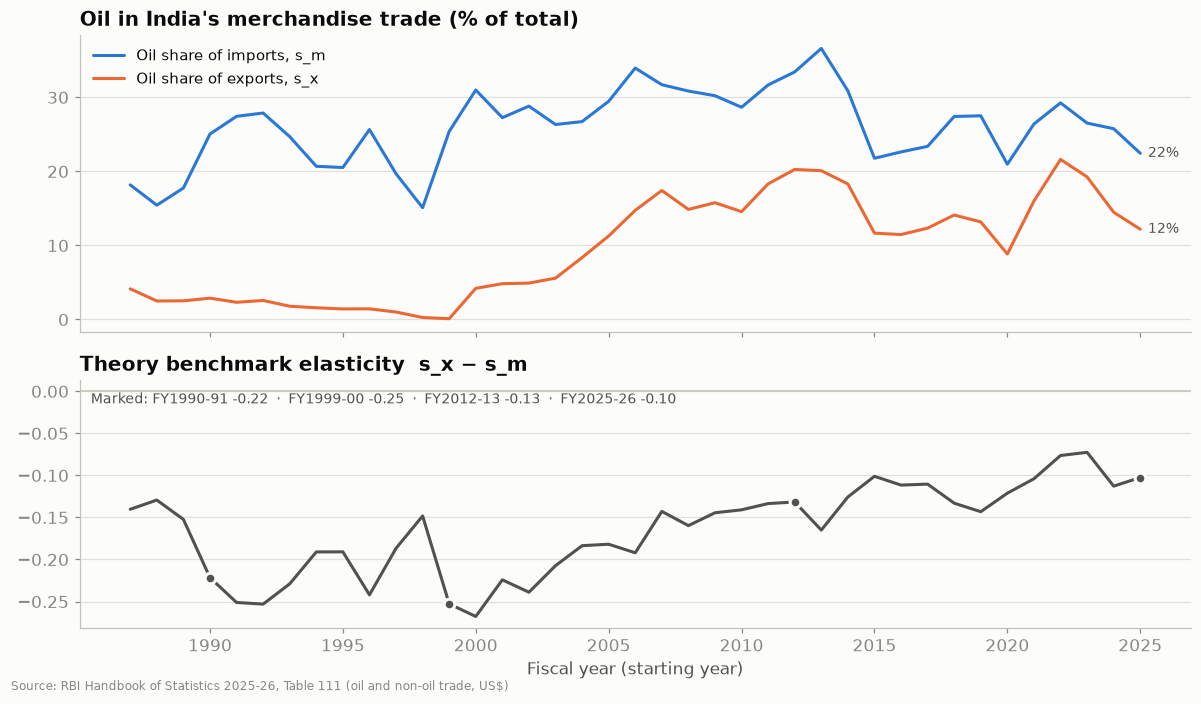

In [5]:
d = a.loc[1987:2025]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True, gridspec_kw={"height_ratios": [1.2, 1]})
ax1.plot(d.index, 100 * d.s_m_oil, color=BLUE, label="Oil share of imports, s_m")
ax1.plot(d.index, 100 * d.s_x_oil, color=ORANGE, label="Oil share of exports, s_x")
ax1.set_title("Oil in India's merchandise trade (% of total)"); ax1.legend(loc="upper left")
for col in ("s_m_oil", "s_x_oil"):
    ax1.annotate(f"{100*d[col].iloc[-1]:.0f}%", (d.index[-1], 100 * d[col].iloc[-1]), xytext=(5, 0),
                 textcoords="offset points", va="center", fontsize=9, color=INK2)
ax2.plot(d.index, d.benchmark_elasticity, color=INK2)
ax2.axhline(0, color=AXIS, lw=1)
ax2.set_title("Theory benchmark elasticity  s_x − s_m")
marks = (1990, 1999, 2012, 2025)
for y in marks:
    ax2.plot([y], [d.loc[y, "benchmark_elasticity"]], "o", ms=7, color=INK2, mec=SURFACE, mew=2, zorder=3)
ax2.text(0.01, 0.95, "Marked: " + "  ·  ".join(f"FY{y}-{str(y+1)[-2:]} {d.loc[y,'benchmark_elasticity']:.2f}" for y in marks),
         transform=ax2.transAxes, ha="left", va="top", fontsize=9, color=INK2)
ax2.set_xlabel("Fiscal year (starting year)")
fig.tight_layout()
save(fig, "fig03_oil_shares_benchmark", "RBI Handbook of Statistics 2025-26, Table 111 (oil and non-oil trade, US$)")
plt.show()

**Reading the chart.**
- Since India began exporting refined products at scale (Jamnagar, around 2000), s_x has risen from about 0% to 12–22%.
- India's *net* exposure, the benchmark elasticity, roughly halved: from about −0.25 (1999-00) to about −0.10 (2025-26).

## 4. Descriptive statistics

In [6]:
desc = pd.DataFrame({
    "ToT goods & services (FY1970-2025)": a.loc[1970:2025, "tot_gs_na"],
    "ToT merchandise chained (FY1994-2025)": a.loc[1994:2025, "ntt_rbi_chained"],
    "Real oil price (FY1970-2024)": a.loc[1970:2024, "real_oil_avg"],
    "Real non-energy index (FY1970-2024)": a.loc[1970:2024, "real_nonenergy"],
    "Oil share of imports (FY1987-2025)": a.loc[1987:2025, "s_m_oil"],
    "Oil share of exports (FY1987-2025)": a.loc[1987:2025, "s_x_oil"],
}).describe().T[["count", "mean", "std", "min", "max"]]
mdesc = m.loc["2019-04":"2026-06", ["ntt_b12", "uvi_x_b12", "uvi_m_b12", "brent"]].describe().T[["count", "mean", "std", "min", "max"]]
mdesc.index = ["Merchandise NTT, monthly", "Export UVI, monthly", "Import UVI, monthly", "Brent US$/bbl, monthly (Apr19-Jun26)"]
desc = pd.concat([desc, mdesc])
save_table(desc, "t01_descriptives")
desc

,count,mean,std,min,max
ToT goods & services (FY1970-2025),56.000,102.989,13.464,69.656,131.564
ToT merchandise chained (FY1994-2025),32.000,81.344,15.058,61.874,113.522
Real oil price (FY1970-2024),55.000,44.379,25.141,5.532,96.743
Real non-energy index (FY1970-2024),55.000,81.047,17.397,55.232,121.566
Oil share of imports (FY1987-2025),39.000,0.260,0.051,0.151,0.366
Oil share of exports (FY1987-2025),39.000,0.096,0.069,0.001,0.216
"Merchandise NTT, monthly",87.000,111.880,13.689,89.450,163.229
"Export UVI, monthly",87.000,153.560,17.846,117.676,203.782
"Import UVI, monthly",87.000,139.988,27.165,93.765,193.608
"Brent US$/bbl, monthly (Apr19-Jun26)",87.000,74.405,19.272,23.300,120.400
